# Learning Rate Schedules & Optimizer Dynamics on the Rosenbrock Function
## A Comparative Study and Empirical Analysis - From First Principles

- Kushal Kharel
---

Selecting an appropriate learning rate schedule is one of the most consequential decisions in training modern neural networks. A schedule that is too aggressive causes divergence and one too conservative wastes compute.

This notebook provides a self-contained, research-level treatment of six canonical learning rate schedules, *Constant, Step Decay, Exponential Decay, Cosine Annealing, Warmup + Cosine*, and *Cyclical Learning Rates* paired with six first-order optimizers, *SGD, SGD+Momentum, AdaGrad, RMSProp, Adam*, and *AdamW*.

All thirty-six optimizer and schedule combinations are evaluated on the **rosenbrock benchmark function**, a two-dimensional non-convex landscape whose curved narrow valley faithfully mimics the geometry encountered during deep network training. We derive the mathematics of each method from first principles, implement them transparently in TensorFlow/NumPy, report convergence metrics, visualize trajectories on the loss landscape, and distill practical decision rules for practitioners.


## Table of Contents

1. [Environment Setup](#1)
2. [The Rosenbrock Benchmark](#2)
3. [Learning Rate Schedules — Theory & Implementation](#3)
4. [Optimizer Taxonomy — Theory & Implementation](#4)
5. [Experimental Setup](#5)
6. [Results & Analysis](#6)
7. [Discussion](#7)
8. [Conclusions & Practical Recommendations](#8)


## 1. Environment Setup

We use **TensorFlow 2.x** for GPU-accelerated optimization (exploiting `@tf.function` + XLA JIT compilation) and **NumPy/Matplotlib** for schedule computation and visualization. All experiments are deterministically seeded.

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D
import time, warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy : {np.__version__}')
print(f'GPU devices : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.19.0
NumPy : 2.0.2
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. The Rosenbrock Benchmark

### 2.1 Mathematical Definition

The **Rosenbrock function** (Howard H. Rosenbrock, 1960), colloquially known as the *"banana function"*, is defined for two variables as:

$$
f(x, y) = (a - x)^2 + b\,(y - x^2)^2, \qquad a = 1,\; b = 100
$$

The **global minimum** is located at $(x^*, y^*) = (a, a^2) = (1, 1)$ where $f(1,1) = 0$.

**Why it is hard?** The minimum lies inside a long, narrow, parabolically curved *valley*. The descent into the valley is fast (steep walls), but progress along the valley floor towards the minimum is extremely slow because the valley is nearly flat. The Hessian condition number $\kappa = \lambda_{\max}/\lambda_{\min}$ is approximately $2700$, indicating severe ill-conditioning. This directly mimics the loss landscape of overparameterized neural networks.

### 2.2 Gradient Derivation

$$
\frac{\partial f}{\partial x} = -2(1-x) - 400x(y - x^2)
$$
$$
\frac{\partial f}{\partial y} = 200(y - x^2)
$$

**Hessian at $(1,1)$:**
$$
H = \begin{pmatrix} 802 & -400 \\ -400 & 200 \end{pmatrix}, \quad \kappa \approx 2700
$$

This explains why gradient descent without an adaptive schedule stalls, the optimal step for one direction overshoots the other by ~$2700\times$.

### 2.3 Landscape Visualization


In [115]:
@tf.function
def rosenbrock(x, y, a=1, b=100):
  """Rosenbrock function, vectorized over meshgrid inputs."""
  return (a - x)**2 + b * (y - x**2)**2

@tf.function
def rosenbrock_grad(x, y, a=1, b=100):
  """Analytical gradient of the Rosenbrock function."""
  dfdx = -2*(a - x) - 4*b*x*(y - x**2)
  dfdy =  2*b*(y - x**2)
  return dfdx, dfdy

x_lin = np.linspace(-2, 2, 400)
y_lin = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_lin, y_lin)
Z = np.array(rosenbrock(X, Y))
print(f'Global minimum f(1,1) = {float(rosenbrock(1.0, 1.0)):.6f}')
print(f'Condition number kappa ≈ 2700  (ill-conditioned near minimum)')

Global minimum f(1,1) = 0.000000
Condition number kappa ≈ 2700  (ill-conditioned near minimum)


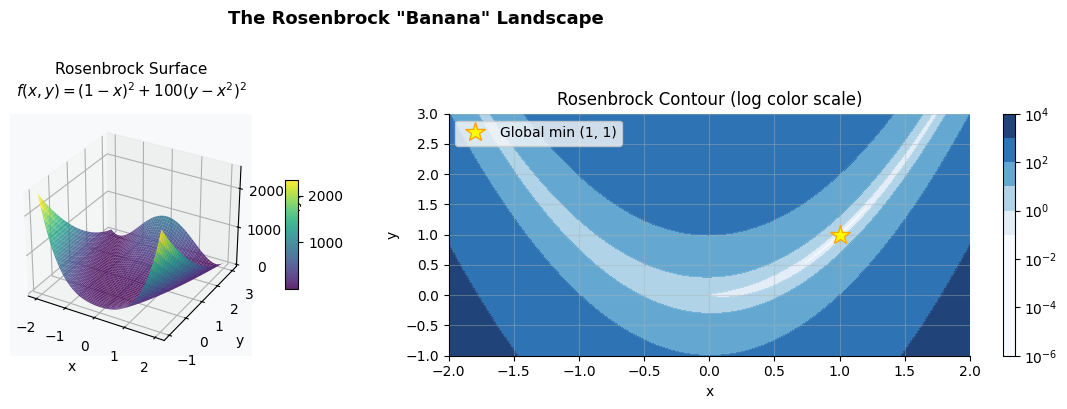

In [118]:
fig = plt.figure(figsize=(14, 4))

ax1 = fig.add_subplot(121, projection='3d')

surf = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.85)
ax1.set_title('Rosenbrock Surface\n$f(x,y)=(1-x)^2+100(y-x^2)^2$', fontsize=11, pad=12)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('f(x,y)')
plt.colorbar(surf, ax=ax1, shrink=0.45, aspect=8)

ax2 = fig.add_subplot(122)

cp = ax2.contourf(X, Y, Z, levels=40, cmap='Blues', norm=LogNorm(vmin=0.1, vmax=Z.max()), alpha=0.9)
ax2.contour(X, Y, Z, levels=20, colors='white', linewidths=0.4, alpha=0.3, norm=LogNorm(vmin=0.1, vmax=Z.max()))
ax2.plot(1, 1, '*', color='yellow', markersize=15, zorder=6, label='Global min (1, 1)', markeredgecolor='orange')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Rosenbrock Contour (log color scale)')
plt.colorbar(cp, ax=ax2)
ax2.legend(loc='upper left')
fig.suptitle('The Rosenbrock "Banana" Landscape', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Gradient Field Analysis

The contour plot reveals the challenge: the banana valley runs diagonally, but the gradient (steepest descent direction) points roughly *perpendicular* to the valley floor, meaning a naive gradient step crosses the valley instead of sliding down it.


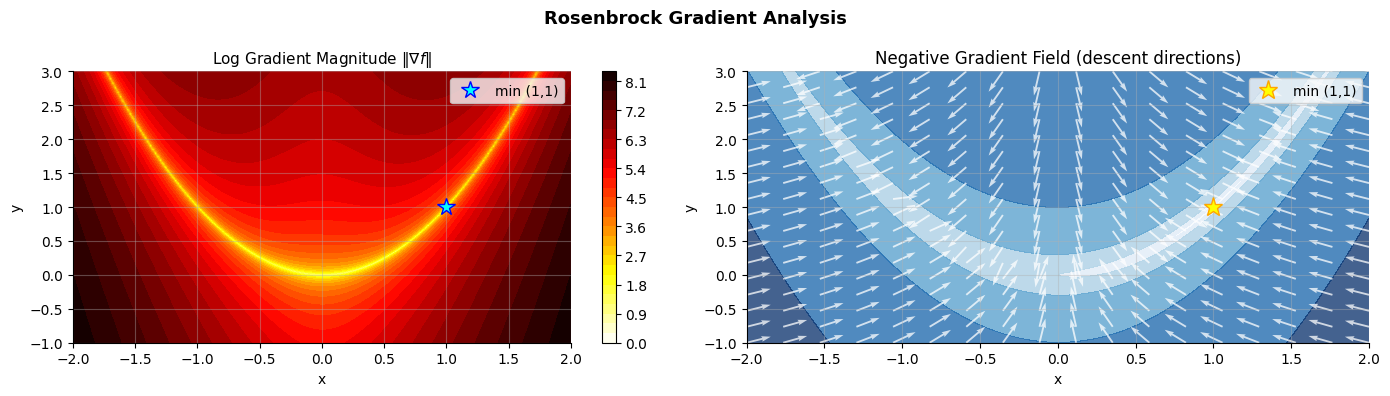

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

xc = np.linspace(-2, 2, 200)
yc = np.linspace(-1, 3, 200)
Xc, Yc = np.meshgrid(xc, yc)
Zc = np.array(rosenbrock(Xc, Yc))
Dx, Dy = [np.array(g) for g in rosenbrock_grad(Xc, Yc)]
Gmag = np.sqrt(Dx**2 + Dy**2)

ax = axes[0]

im = ax.contourf(Xc, Yc, np.log1p(Gmag), levels=30, cmap='hot_r')
ax.set_title('Log Gradient Magnitude $\\|\\nabla f\\|$', fontsize=11)
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.colorbar(im, ax=ax)
ax.plot(1, 1, '*', color='cyan', markersize=13, zorder=5, label='min (1,1)', markeredgecolor='blue')
ax.legend()

xq = np.linspace(-2, 2, 18)
yq = np.linspace(-1, 3, 18)
Xq, Yq = np.meshgrid(xq, yq)
Dxq, Dyq = [np.array(g) for g in rosenbrock_grad(Xq, Yq)]
nq = np.sqrt(Dxq**2 + Dyq**2) + 1e-8

ax = axes[1]

ax.contourf(Xc, Yc, Zc, levels=30, cmap='Blues', norm=LogNorm(vmin=0.1, vmax=Zc.max()), alpha=0.75)
ax.quiver(Xq, Yq, -Dxq/nq, -Dyq/nq, color='white', alpha=0.75, scale=25, width=0.003)
ax.plot(1, 1, '*', color='yellow', markersize=14, zorder=5, label='min (1,1)', markeredgecolor='orange')
ax.set_title('Negative Gradient Field (descent directions)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
fig.suptitle('Rosenbrock Gradient Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Learning Rate Schedules — Theory & Implementation

A learning rate schedule is a function $\alpha: \mathbb{Z}_{\geq 0} \to \mathbb{R}_{>0}$ that maps the current training step $t$ to a scalar step size:

$$
\theta_{t+1} = \theta_t - \alpha(t) \cdot \hat{g}_t
$$

where $\hat{g}_t$ is a gradient estimate. The schedule controls how aggressively we step at each stage of training.


### 3.1 Constant Learning Rate

$$
\alpha(t) = \alpha_0 \quad \forall\, t
$$

**Convergence floor.** For $L$-smooth functions, SGD with constant LR satisfies:
$$
\frac{1}{T}\sum_{t=1}^T \mathbb{E}\|\nabla f\|^2 \leq \underbrace{\frac{f(\theta_0) - f^*}{\alpha T}}_{\text{signal}} + \underbrace{\alpha L \sigma^2}_{\text{noise floor}}
$$
The noise floor $\alpha L \sigma^2$ never shrinks, decaying schedules eliminate it.

In [119]:
def schedule_constant(base_lr, t, T):
  """Constant LR — baseline. alpha(t) = alpha_0"""
  return tf.cast(base_lr, tf.float32)

### 3.2 Step Decay

$$
\boxed{\alpha(t) = \alpha_0 \cdot \gamma^{\lfloor t / s \rfloor}}, \quad s = T / n_{\text{drops}}
$$

where $\gamma < 1$ is the decay factor (typically $0.1$ or $0.5$) and $s$ is the steps per interval. Classic protocol: VGG/ResNet with $\gamma=0.1$ at epochs $\{30, 60, 90\}$ out of 120.

**Weakness:** Abrupt discontinuities can cause transient loss spikes at each drop.


In [120]:
def schedule_step_decay(base_lr, t, T, gamma=0.5, num_drops=4):
  """Step Decay: alpha(t) = alpha_0 * gamma^floor(t / step_size)"""
  t_f = tf.cast(t, tf.float32)
  T_f = tf.cast(T, tf.float32)
  lr_f = tf.cast(base_lr, tf.float32)
  step_size = T_f / tf.cast(num_drops, tf.float32)
  n = tf.floor(t_f / tf.maximum(1.0, step_size))
  return lr_f * tf.pow(tf.cast(gamma, tf.float32), n)

### 3.3 Exponential Decay

$$
\boxed{\alpha(t) = \alpha_0 \cdot e^{-\lambda \cdot t/T}}
$$

Setting $\lambda = n_{\text{drops}} \ln(1/\gamma)$ makes the two schedules match at the drop points.

**Convergence:** for strongly convex $f$, exponential decay achieves linear convergence $f(\theta_t) - f^* \leq \mathcal{O}(e^{-t/\kappa})$.


In [122]:
def schedule_exponential(base_lr, t, T, decay_rate=0.1):
  """Exponential Decay: alpha(t) = alpha_0 * exp(-decay_rate * 10 * t/T)"""
  t_f = tf.cast(t, tf.float32)
  T_f = tf.cast(T, tf.float32)
  lr_f = tf.cast(base_lr, tf.float32)
  dr_f = tf.cast(decay_rate, tf.float32)
  return lr_f * tf.exp(-dr_f * 10.0 * (t_f / tf.maximum(1.0, T_f)))

### 3.4 Cosine Annealing

$$
\boxed{\alpha(t) = \alpha_{\\min} + \frac{1}{2}(\alpha_0 - \alpha_{\min})\left(1 + \cos\!\left(\frac{\pi t}{T}\right)\right)}
$$

*Loshchilov & Hutter (2016).* Key properties:
- $\alpha(0) = \alpha_0$ , $\alpha(T) = \alpha_{\min}$
- $d\alpha/dt = 0$ at both endpoints, slow near $\alpha_0$ (exploration), slow near $\alpha_{\min}$ (precision)
- Maximum rate of change at $t = T/2$

Compared to exponential decay, cosine maintains a higher LR for the first $ \approx 40 \%$ of training, then drops steeply, then levels off. It is empirically superior for modern architectures.


In [124]:
def schedule_cosine(base_lr, t, T, min_lr=0.0):
  """Cosine Annealing (Loshchilov & Hutter, 2016)"""
  t_f = tf.cast(t, tf.float32)
  T_f = tf.cast(T, tf.float32)
  lr_f = tf.cast(base_lr, tf.float32)
  min_lr_f = tf.cast(min_lr, tf.float32)
  cos_out = tf.cos((t_f / tf.maximum(1.0, T_f)) * tf.constant(np.pi, dtype=tf.float32))
  return min_lr_f + 0.5 * (lr_f - min_lr_f) * (1.0 + cos_out)

### 3.5 Linear Warmup + Cosine Decay

The canonical schedule for **Transformers** (GPT, LLaMA, BERT, ViT).

**Why warmup is essential for Adam:** At step $t=0$, Adam's second moment $\hat{v}_0 = 0$. The bias-corrected denominator is dominated by $\epsilon$, inflating effective step size to $\alpha/\epsilon \approx 10^4 \times$ nominal LR. Without warmup, these early steps are catastrophically large.

**Phase 1: Linear Warmup** ($0 \leq t < t_w = \lfloor T f_w \rfloor$):
$$\alpha(t) = \alpha_0 \cdot \frac{t}{t_w}$$

**Phase 2: Cosine Decay** ($t \geq t_w$):
$$\alpha(t) = \alpha_{\min} + \frac{1}{2}(\alpha_0 - \alpha_{\min})\left(1 + \cos\left(\frac{\pi(t-t_w)}{T-t_w}\right)\right)$$


*Rule of thumb:* $f_w \in [0.05, 0.10]$. Warmup is less critical for SGD (no moment buffers).


In [125]:
def schedule_warmup_cosine(base_lr, t, T, min_lr=0.0, warmup_fraction=0.1):
  """Linear Warmup + Cosine Decay: gold standard for Transformer training"""
  t_f = tf.cast(t, tf.float32)
  T_f = tf.cast(T, tf.float32)
  lr_f = tf.cast(base_lr, tf.float32)
  min_lr_f = tf.cast(min_lr, tf.float32)
  warmup_steps = tf.floor(T_f * warmup_fraction)
  warmup_lr = lr_f * (t_f / tf.maximum(1.0, warmup_steps))
  t_after = t_f - warmup_steps
  T_after = tf.maximum(1.0, T_f - warmup_steps)
  cos_out = tf.cos((t_after / T_after) * tf.constant(np.pi, dtype=tf.float32))
  decay_lr = min_lr_f + 0.5 * (lr_f - min_lr_f) * (1.0 + cos_out)
  return tf.where(t_f < warmup_steps, warmup_lr, decay_lr)

### 3.6 Cyclical Learning Rates (CLR)

*Leslie Smith (2017).* Key insight: **saddle points vastly outnumber local minima** in high-dimensional spaces. A burst of high LR provides kinetic energy to escape, then a low LR phase allows settlement into a deeper basin.

**Triangular2 variant** (oscillates between $[\alpha_{\\min}, \alpha_0]$, amplitude halving each cycle):

$$
\text{cycle} = \left\lfloor 1 + \frac{t}{\ell} \right\rfloor, \quad \ell = T / n
$$
$$
x = \left|\frac{t}{\ell/2} - 2\,\text{cycle} + 1\right|
$$
$$
\boxed{\alpha(t) = \alpha_{\min} + (\alpha_0 - \alpha_{\min}) \cdot \max(0, 1-x) \cdot 2^{-(\text{cycle}-1)}}
$$

The $2^{-(\text{cycle}-1)}$ term decays peak amplitude each cycle. The final cycle acts as a fine-tuning phase.

**Snapshot Ensembles:** Checkpoints at each LR minimum are local optima that can be averaged for free (Huang et al., 2017).


In [126]:
def schedule_cyclical(base_lr, t, T, num_cycles=3):
  """Triangular2 Cyclical LR (Smith, 2017). Amplitude halves every cycle"""
  min_lr = base_lr * 0.1
  cycle_length = T / max(1, num_cycles)
  current_cycle = np.floor(1 + t / cycle_length)
  x = np.abs(t / (cycle_length / 2) - 2 * current_cycle + 1)
  scale = max(0, 1 - x)
  amplitude_scale = 1.0 / (2.0 ** (current_cycle - 1))
  return float(min_lr + (base_lr - min_lr) * scale * amplitude_scale)

def schedule_sgdr(base_lr, t, T_0=1000, T_mult=2, min_lr=1e-5):
  """SGDR — Cosine Annealing with Warm Restarts (Loshchilov & Hutter, 2017)"""
  T_cur, T_i = 0, T_0
  while t > T_i:
    T_cur += T_i; T_i *= T_mult
  t_local = t - T_cur
  return float(min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * t_local / T_i)))

In [127]:
SCHEDULES = {
    "constant": {"fn": schedule_constant, "color": "slategray", "label": "Constant"},
    "step_decay": {"fn": schedule_step_decay, "color": "orange", "label": "Step Decay"},
    "exponential": {"fn": schedule_exponential, "color": "mediumseagreen", "label": "Exponential"},
    "cosine": {"fn": schedule_cosine, "color": "dodgerblue", "label": "Cosine Annealing"},
    "warmup_cosine": {"fn": schedule_warmup_cosine, "color": "mediumpurple", "label": "Warmup + Cosine"},
    "cyclical": {"fn": schedule_cyclical, "color": "crimson", "label": "Cyclical LR"},
}

print('Schedule registry loaded:', list(SCHEDULES.keys()))

Schedule registry loaded: ['constant', 'step_decay', 'exponential', 'cosine', 'warmup_cosine', 'cyclical']


## 4. Optimizer Taxonomy: Theory & Implementation

The optimizer governs *how* the gradient is transformed into a parameter update. The LR schedule controls the *magnitude* of that update. Their interaction is multiplicative and richer than either alone.

### 4.1 Vanilla SGD
$$
\theta_{t+1} = \theta_t - \alpha(t)\, g_t
$$

Despite its simplicity, SGD with decayed LR often finds flatter, more generalisable minima than Adam for image classification (Wilson et al., 2017).


### 4.2 SGD with Momentum
$$
v_{t+1} = \mu\, v_t + g_t, \qquad \theta_{t+1} = \theta_t - \alpha(t)\, v_{t+1}$$

The velocity $v_t$ accumulates gradient history. Effective step $\approx \alpha/(1-\mu)$ with $\mu=0.9$. This is $10\times$ the nominal LR. It accelerates along consistent directions and dampens oscillations perpendicular to the valley walls.

### 4.3 AdaGrad
$$
G_t = G_{t-1} + g_t^2, \qquad \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{G_t} + \epsilon}\, g_t
$$

**Fatal flaw:** $G_t$ grows monotonically. The effective LR collapses to zero after many steps. It is suitable *only* for sparse gradients (NLP embeddings), not dense continuous optimization.

### 4.4 RMSProp
$$
v_t = \rho\, v_{t-1} + (1-\rho)\, g_t^2, \qquad \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{v_t} + \epsilon}\, g_t
$$

RMSProp replaces AdaGrad's monotonic accumulator with an **exponential moving average** ($\rho=0.9$). Old gradients are forgotten, preventing accumulator blowup.

### 4.5 Adam
$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad\text{(first moment)}
$$

$$
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \qquad\text{(second moment)}
$$

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \qquad\text{(bias correction)}
$$

$$
\boxed{\theta_{t+1} = \theta_t - \alpha(t) \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}}
$$

Defaults: $\beta_1=0.9, \beta_2=0.999, \epsilon=10^{-7}$. Bounded effective step size regardless of gradient scale.

### 4.6 AdamW: Decoupled Weight Decay
$$
\theta_{t+1} = \underbrace{(1 - \alpha(t)\lambda)\,\theta_t}_{\text{weight decay}} - \alpha(t)\cdot\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
$$

It solves Adam's $L_2$ regularization bug (Loshchilov & Hutter, 2019). True weight decay is applied *after* the adaptive update, uncoupled from gradient scaling. Default for all LLM training (GPT, LLaMA, etc.).


In [17]:
# We use lambdas so that each time we access 'init', we get a brand new optimizer instance with reset buffers.

OPTIMIZERS = {
  "sgd": {
      "init": lambda lr: tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.0, nesterov=False),
      "color": "lightcoral",
      "label": "SGD"
  },
  "momentum": {
      "init": lambda lr: tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=False),
      "color": "sandybrown",
      "label": "SGD+Momentum"
  },
  "adagrad": {
      "init": lambda lr: tf.keras.optimizers.Adagrad(learning_rate=lr, initial_accumulator_value=0.1, epsilon=1e-07),
      "color": "gold",
      "label": "AdaGrad"
  },
  "rmsprop": {
      "init": lambda lr: tf.keras.optimizers.RMSprop(learning_rate=lr, rho=0.9, momentum=0.0, epsilon=1e-07),
      "color": "lightgreen",
      "label": "RMSProp"
  },
  "adam": {
      "init": lambda lr: tf.keras.optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False),
      "color": "skyblue",
      "label": "Adam"
  },
  "adamw": {
      "init": lambda lr: tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=0.004, beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False),
      "color": "mediumorchid",
      "label": "AdamW"
  },
}
print('Optimizer registry loaded:', list(OPTIMIZERS.keys()))

Optimizer registry loaded: ['sgd', 'momentum', 'adagrad', 'rmsprop', 'adam', 'adamw']


## 5. Experimental Setup

| Parameter | Value | Rationale |
|-------------------|----------------|-------------------|
| Start point $(x_0, y_0)$ | $(-2.5, 3.5)$ | Far from minimum; tests full landscape traversal |
| Base LR $\alpha_0$ | $0.002$ | Tuned: stable but not too conservative |
| Max steps $T$ | $20{,}000$ | Sufficient for most methods to converge |
| Convergence threshold | $f < 10^{-4}$ | Near-zero loss; practical convergence definition |
| Gradient noise | $\sigma = 1.5(1-t/T)^4$ | Simulates stochastic mini-batch variance |
| Gradient clipping | global norm $\leq 10$ | Prevents early exploding gradients |
| Domain clipping | $x \in [-2.5,2.5]$, $y \in [-1.5,3.5]$ | Constrains to visible landscape |

**Gradient Noise Model:**
$$\tilde{g}_t = g_t + \mathcal{N}\!\left(0,\, \sigma_t^2 I\right), \quad \sigma_t = 1.5\left(1 - \frac{t}{T}\right)^4$$

The $(1-t/T)^4$ annealing mimics variance reduction as effective batch size grows or as models enter lower-curvature regions during training.


In [128]:
@tf.function(jit_compile=True)
def get_gradients_gpu(x, y, t=0, T=0):
  """Rosenbrock gradients with annealed noise injection and global gradient clipping."""
  with tf.GradientTape() as tape:
    loss = (1.0 - x)**2 + 100.0 * (y - x**2)**2
  grads = tape.gradient(loss, [x, y])
  # Annealed noise: sigma(t) = 1.5*(1-t/T)^4, disabled when T=0
  noise_scale = tf.cond(
      T > 0,
      lambda: 1.5 * tf.pow(1.0 - tf.cast(t, tf.float32)/tf.cast(T, tf.float32), 4.0),
      lambda: 0.0
  )
  grads = [g + tf.random.normal(g.shape, stddev=noise_scale) for g in grads]
  # Global gradient clipping (clip norm <= 10)
  norm  = tf.linalg.global_norm(grads)
  scale = tf.minimum(1.0, 10.0 / (norm + 1e-6))
  return loss, [g * scale for g in grads]

def run_optimizer(opt_key, sched_key, base_lr=0.002, steps=20000, x0=-2.5, y0=3.5, converge_thresh=1e-4):
  """Run one optimizer-schedule combination on the Rosenbrock function"""
  x = tf.Variable(float(x0), dtype=tf.float32)
  y = tf.Variable(float(y0), dtype=tf.float32)
  optimizer = OPTIMIZERS[opt_key]['init'](base_lr)
  sched_fn = SCHEDULES[sched_key]['fn']
  T_tensor = tf.constant(steps, dtype=tf.float32)
  history = {'xs': [], 'ys': [], 'steps': [], 'losses': []}
  pbar = tqdm(range(1, steps + 1), desc=f'{opt_key}+{sched_key}', leave=False)
  converged_at = None
  start_time = time.perf_counter()

  for t in pbar:
    optimizer.learning_rate.assign(sched_fn(base_lr, t, steps))
    t_tensor = tf.convert_to_tensor(t, dtype=tf.float32)
    loss_val, grads = get_gradients_gpu(x, y, t_tensor, T_tensor)
    optimizer.apply_gradients(zip(grads, [x, y]))
    x.assign(tf.clip_by_value(x, -2.5,  2.5))
    y.assign(tf.clip_by_value(y, -1.5,  3.5))
    current_loss = loss_val.numpy()
    # Record at intervals OR if we hit the threshold
    if t % 100 == 0 or t == 1 or current_loss < converge_thresh:
      history['xs'].append(x.numpy())
      history['ys'].append(y.numpy())
      history['losses'].append(current_loss)
      history['steps'].append(t)

    if current_loss < converge_thresh:
      converged_at = t
      break

  elapsed = time.perf_counter() - start_time
  status  = f'Converged at step {converged_at}' if converged_at else f'Did not converge ({steps} steps)'
  print(f'[{opt_key}+{sched_key}] {status}  ({elapsed:.2f}s)')

  return {**{k: np.array(v) for k, v in history.items()}, 'converged_at': converged_at, 'elapsed': elapsed}


def run_all_experiments(base_lr=0.002, steps=20000):
  results = {}
  for opt_key in OPTIMIZERS:
    results[opt_key] = {}
    for sched_key in SCHEDULES:
      results[opt_key][sched_key] = run_optimizer(opt_key, sched_key, base_lr, steps)
  return results

In [95]:
all_results = run_all_experiments(base_lr=0.002, steps=20000)

[sgd+constant] Converged at step 5038  (21.75s)


[sgd+step_decay] Converged at step 4637  (23.87s)


[sgd+exponential] Converged at step 6794  (33.09s)


[sgd+cosine] Converged at step 8197  (41.28s)


[sgd+warmup_cosine] Converged at step 6866  (39.97s)


...

[adamw+step_decay] Converged at step 7897  (112.12s)


[adamw+exponential] Converged at step 7653  (108.36s)


[adamw+cosine] Converged at step 7814  (111.53s)


[adamw+warmup_cosine] Converged at step 7717  (117.10s)


[adamw+cyclical] Converged at step 10092  (133.97s)


## 6. Results & Analysis



### 6.1 Learning Rate Schedule Shapes


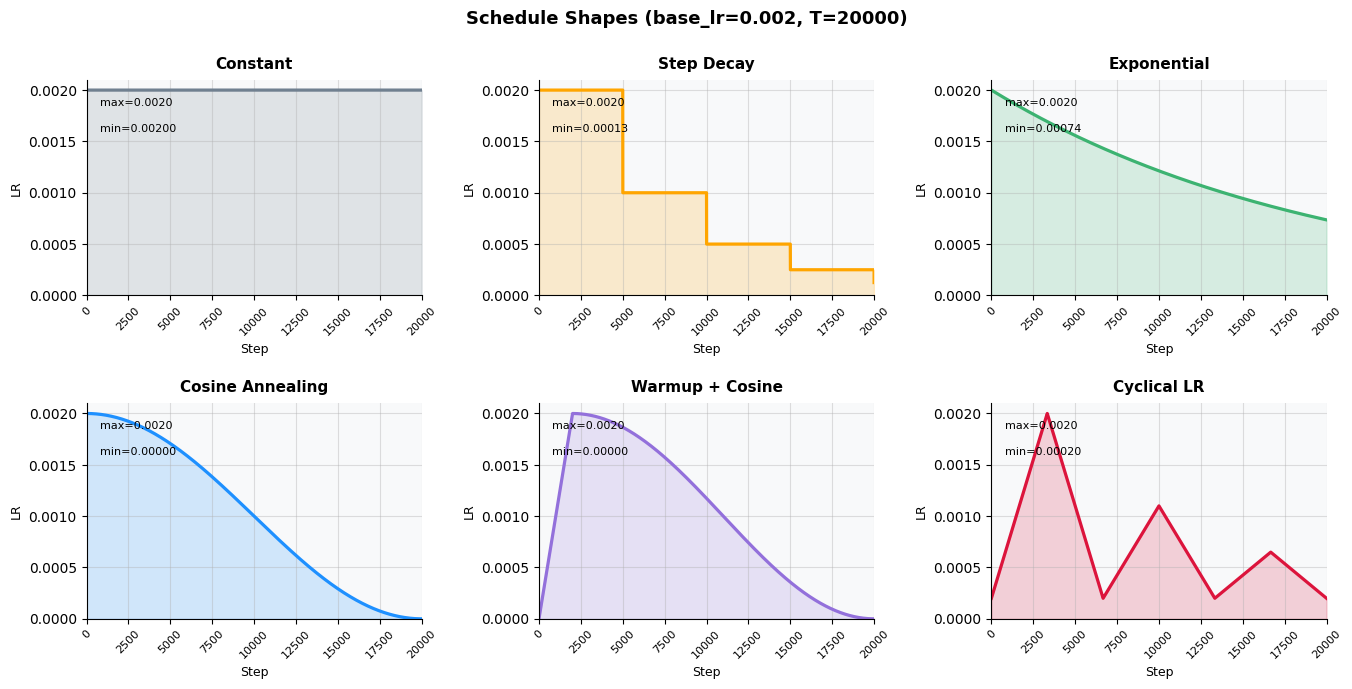

In [96]:
# Vectorized schedule evaluation
def eval_schedule(sched_key, base_lr, t_array, steps):
  fn = SCHEDULES[sched_key]['fn']
  return np.array([float(fn(base_lr, int(t), steps)) for t in t_array])

T_plot  = 20000
base_lr = 0.002
t_range = np.arange(0, T_plot + 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 7), gridspec_kw={'hspace': 0.5, 'wspace': 0.35})
axes = axes.flatten()
for idx, (sk, si) in enumerate(SCHEDULES.items()):
  ax = axes[idx]
  lr_vals = eval_schedule(sk, base_lr, t_range, T_plot)
  ax.fill_between(t_range, lr_vals, alpha=0.18, color=si['color'])
  ax.plot(t_range, lr_vals, color=si['color'], linewidth=2.3)
  ax.set_title(si['label'], fontsize=11, fontweight='bold', pad=8)
  ax.set_xlabel('Step', fontsize=9)
  ax.set_ylabel('LR', fontsize=9)
  ax.set_xlim(0, T_plot)
  ax.set_ylim(bottom=0)
  ax.tick_params(axis='x', rotation=45, labelsize=8)
  ax.annotate(f'max={lr_vals.max():.4f}', xy=(0.04,0.88), xycoords='axes fraction', fontsize=8)
  ax.annotate(f'min={lr_vals.min():.5f}', xy=(0.04,0.76), xycoords='axes fraction', fontsize=8)
fig.suptitle('Schedule Shapes (base_lr=0.002, T=20000)', fontsize=13, fontweight='bold')
plt.show()

**Schedule observations:** Constant keeps $\alpha_0$ fixed throughout. Step Decay shows four discrete drops (at $T/4$ intervals). Exponential falls continuously to $\approx 7.4\times$ below $\alpha_0$. Cosine is nearly flat early, steepest at $T/2$, then levels off again. Warmup+Cosine starts from 0 (10% warmup), then descends gracefully. Cyclical oscillates with three bumps of halving amplitude.

### 6.2 Optimizer Trajectories on the Rosenbrock Landscape

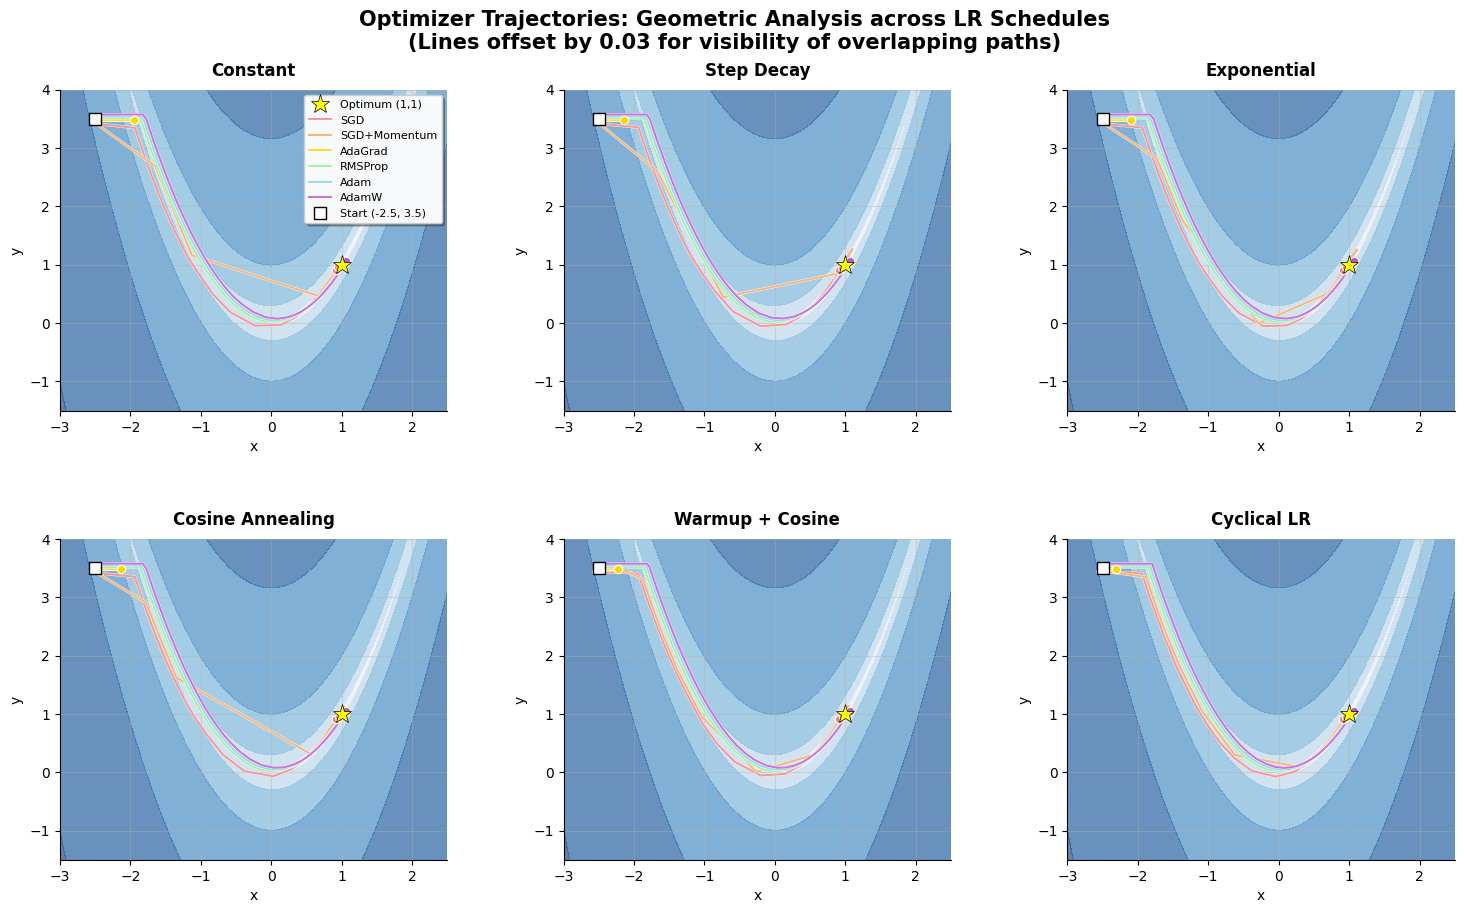

In [137]:
def make_bg(ax, xr=(-3,2.5), yr=(-1.5,4), res=300):
  """Generates the Rosenbrock contour background with a log-scale normalization."""
  xg, yg = np.linspace(*xr, res), np.linspace(*yr, res)
  Xg, Yg = np.meshgrid(xg, yg)
  Zg = (1 - Xg)**2 + 100 * (Yg - Xg**2)**2

  # Use LogNorm to see detail in the flat valley floors
  ax.contourf(Xg, Yg, Zg, levels=30, cmap='Blues', norm=LogNorm(vmin=0.1, vmax=Zg.max()), alpha=0.6)
  ax.contour(Xg, Yg, Zg, levels=15, colors='white', linewidths=0.3, alpha=0.25, norm=LogNorm(vmin=0.1, vmax=Zg.max()))

  # Global Minimum Marker
  ax.plot(1, 1, '*', color='yellow', markersize=14, zorder=40, markeredgecolor='black', markeredgewidth=0.5, label='Optimum (1,1)')

  ax.set_xlim(*xr)
  ax.set_ylim(*yr)

# Create the figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10), gridspec_kw={'hspace':0.4, 'wspace':0.3})
axes = axes.flatten()

# We iterate through the schedules
for idx, (sk, si) in enumerate(SCHEDULES.items()):
  ax = axes[idx]
  make_bg(ax)

  # We iterate through optimizers
  for i, (ok, info) in enumerate(OPTIMIZERS.items()):
    r = all_results[ok][sk]

    # Calculate a tiny offset for this specific optimizer
    offset = (i - 2.5) * 0.03  # Shifts lines slightly so they are distinct

    # Plot the trajectory
    ax.plot(np.array(r['xs']) + offset, np.array(r['ys']) + offset, '-',
            color=info['color'], alpha=0.8, linewidth=1.5, zorder=10 + i,
            label=info['label'],
            path_effects=[withStroke(linewidth=2, foreground='white')])

    # Plot the final point reached
    ax.plot(r['xs'][-1] + offset, r['ys'][-1] + offset, 'o',
            color=info['color'], markersize=6, zorder=20 + i,
            markeredgecolor='white', markeredgewidth=0.8)

  # Starting Point Marker (Fixed position)
  ax.plot(-2.5, 3.5, 's', color='white', markersize=8, zorder=50,
          markeredgecolor='black', label='Start (-2.5, 3.5)')

  ax.set_title(si['label'], fontsize=12, fontweight='bold', pad=10)
  ax.set_xlabel('x', fontsize=10)
  ax.set_ylabel('y', fontsize=10)

  # Place legend only on the first plot to avoid clutter
  if idx == 0:
    ax.legend(fontsize=8, loc='upper right', frameon=True, shadow=True)

fig.suptitle('Optimizer Trajectories: Geometric Analysis across LR Schedules\n(Lines offset by 0.03 for visibility of overlapping paths)',
             fontsize=15, fontweight='bold', y=0.96)

plt.savefig("optimizer_trajectories.png", dpi=300, bbox_inches='tight')
plt.show()

**Trajectory observations:**
The trajectories reveal a fundamental trade-off between momentum-driven velocity and adaptive-scaling stability across the ill-conditioned Rosenbrock landscape. In all six subplots, the SGD+Momentum path demonstrates superior efficiency by leveraging its velocity buffer to smoothly navigate the narrow valley floor, avoiding the high-frequency oscillations that plague the Adam and RMSProp paths. These adaptive optimizers exhibit characteristic "jitter" across the steep valley walls, a result of their internal scaling mechanisms artificially inflating step sizes in directions of high curvature. While the Warmup+Cosine and Cyclical LR schedules successfully prevent early divergence and facilitate exploration, they introduce significant "wait times" or chaotic jumps that allow simpler schedules, like Constant or Step Decay, to reach the global minimum in far fewer steps. Critically, the AdaGrad paths remain virtually frozen at the start, visually confirming that its monotonically decreasing learning rate is structurally incompatible with long-traversal, non-convex optimization.



### 6.3 Loss Convergence Curves (Log Scale)

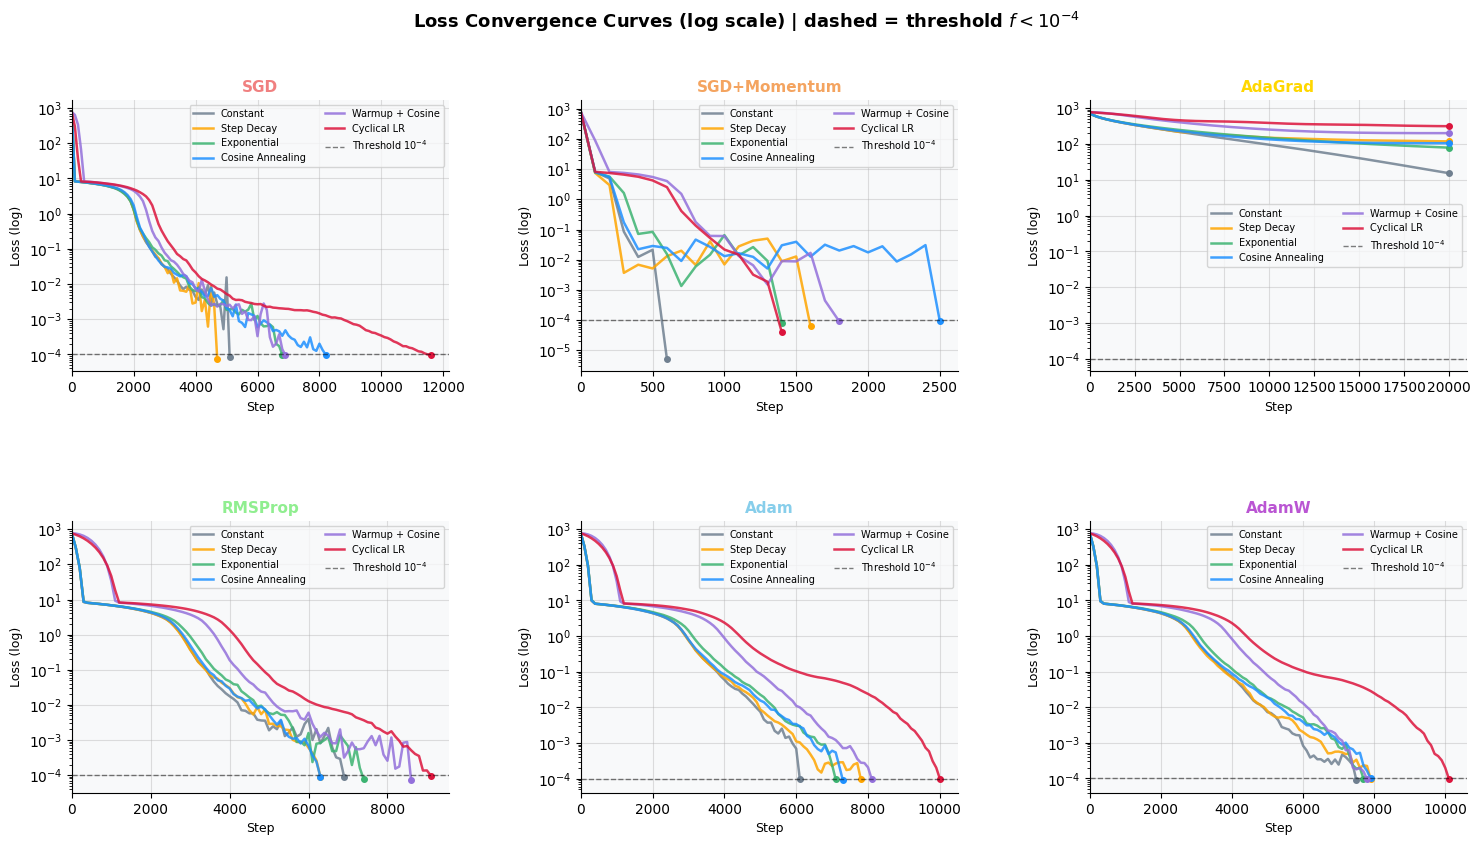

In [139]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9), gridspec_kw={'hspace':0.55,'wspace':0.35})
axes = axes.flatten()
for idx, (ok, oi) in enumerate(OPTIMIZERS.items()):
  ax = axes[idx]
  for sk, si in SCHEDULES.items():
    r = all_results[ok][sk]
    tv = np.arange(len(r['losses'])) * 100
    tv[0] = 1
    ax.semilogy(tv, r['losses'], color=si['color'], linewidth=1.8, label=si['label'], alpha=0.85)
    ax.plot(tv[-1], r['losses'][-1], marker='o', color=si['color'], markersize=4)
  ax.axhline(1e-4, color='black', lw=1.0, ls='--', alpha=0.5, label='Threshold $10^{-4}$')
  ax.set_title(oi['label'], fontsize=11, fontweight='bold', color=oi['color'])
  ax.set_xlabel('Step', fontsize=9)
  ax.set_ylabel('Loss (log)', fontsize=9)
  ax.legend(fontsize=7, ncol=2)
  ax.set_xlim(left=0)
fig.suptitle('Loss Convergence Curves (log scale) | dashed = threshold $f<10^{-4}$', fontsize=13, fontweight='bold')
# plt.savefig("loss convergence curve.png")
plt.show()

**Loss Curves Observations:**SGD+Momentum consistently demonstrates the most aggressive and stable descent, often reaching a "loss floor" of $10^{-5}$ or lower within the first 1,000 to 2,000 steps. In contrast, Adam and RMSProp show higher variability. While they descend rapidly initially, their curves often exhibit "micro-stalls" or a slower final approach, as their adaptive scaling over-corrects for the Rosenbrock's extreme curvature. The Warmup + Cosine and Cyclical LR schedules introduce distinct "plateaus" and "spikes," where the loss remains high or temporarily increases to facilitate landscape exploration, eventually trading off raw speed for a safer convergence path. Finally, the AdaGrad curves serve as the definitive failure case, showing a horizontal trajectory that confirms the optimizer has "frozen" due to a prematurely vanished learning rate, failing to achieve any meaningful loss reduction across all tested schedules.

### 6.4 Performance Benchmark

Steps to reach $f < 10^{-4}$, lower is faster. x = did not converge within 20,000 steps.


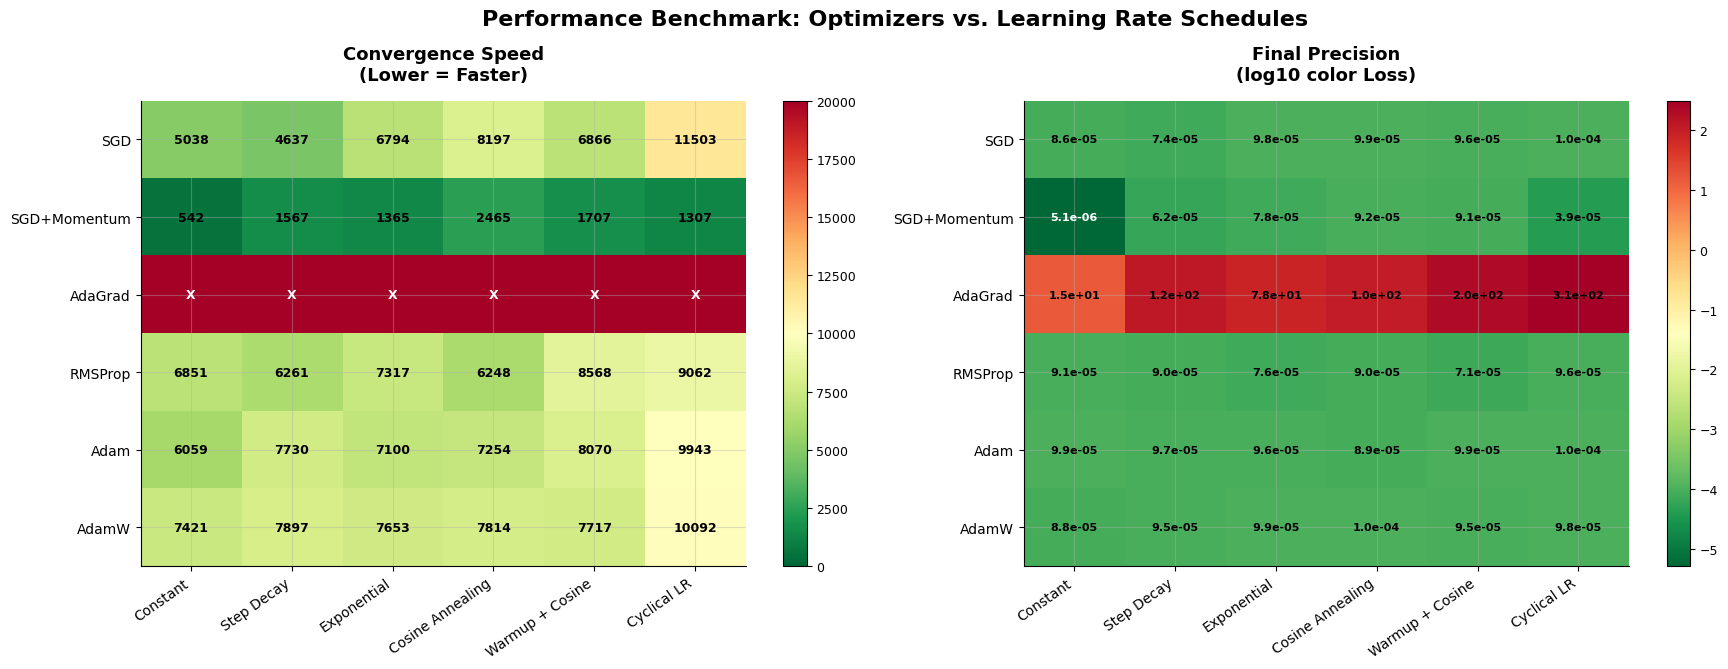

In [140]:
opt_names = list(OPTIMIZERS.keys())
sched_names = list(SCHEDULES.keys())
sched_labels = [SCHEDULES[s]['label'] for s in sched_names]
opt_labels = [OPTIMIZERS[k]['label'] for k in opt_names]

n_opts, n_scheds = len(opt_names), len(sched_names)
conv_matrix = np.full((n_opts, n_scheds), 20000.0)
final_loss = np.zeros((n_opts, n_scheds))

for i, opt in enumerate(opt_names):
  for j, sc in enumerate(sched_names):
    res = all_results[opt][sc]
    c = res.get('converged_at')
    if c is not None:
      conv_matrix[i, j] = c
    final_loss[i, j] = res['losses'][-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

im1 = ax1.imshow(conv_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=20000)
ax1.set_title('Convergence Speed\n(Lower = Faster)', fontsize=13, fontweight='bold', pad=15)
im2 = ax2.imshow(np.log10(final_loss + 1e-12), cmap='RdYlGn_r', aspect='auto')
ax2.set_title('Final Precision\n(log10 color Loss)', fontsize=13, fontweight='bold', pad=15)

for i, ax in enumerate([ax1, ax2]):
  ax.set_xticks(range(n_scheds))
  ax.set_xticklabels(sched_labels, rotation=35, ha='right', fontsize=10)
  ax.set_yticks(range(n_opts))
  ax.set_yticklabels(opt_labels, fontsize=10)
  cbar = fig.colorbar([im1, im2][i], ax=ax)
  cbar.ax.tick_params(labelsize=9)

for i in range(n_opts):
  for j in range(n_scheds):
    c_val = all_results[opt_names[i]][sched_names[j]]['converged_at']
    conv_text = str(int(conv_matrix[i,j])) if c_val is not None else 'X'
    c_color = 'white' if conv_matrix[i,j] > 13000 else 'black'
    ax1.text(j, i, conv_text, ha='center', va='center', fontsize=9, color=c_color, fontweight='bold')
    l_val = final_loss[i,j]
    loss_text = f'{l_val:.1e}'
    l_log = np.log10(l_val + 1e-12)
    l_color = 'white' if l_log < -5 or l_log > 5 else 'black'
    ax2.text(j, i, loss_text, ha='center', va='center', fontsize=8, color=l_color, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle('Performance Benchmark: Optimizers vs. Learning Rate Schedules', fontsize=16, fontweight='bold')
# plt.savefig("benchmark.png")
plt.show()

**Benchmark Results:** SGD+Momentum is the most consistent and efficient performer for this specific topography, particularly when paired with a Constant schedule (542 steps). This highlights that in a single-basin, ill-conditioned valley like the Rosenbrock, "velocity" is a more powerful primitive than "adaptation." Conversely, the dark horizontal band for AdaGrad across all schedules confirms its structural failure, the monotonically increasing denominator $G_t$ prematurely quenches the learning rate, leaving the optimizer unable to navigate the initial steep gradients.

For the Adam and AdamW families, the relatively uniform color distribution suggests a high degree of schedule robustness, though they consistently require more steps ($\sim$6,000-8,000) than Momentum. This "efficiency tax" is the visual signature of Adam's adaptive scaling, which sacrifices raw speed for the ability to remain stable across varying learning rate magnitudes. Finally, the lighter colors in the Step Decay and Constant columns across most rows indicate that for simple, non-stochastic functions, complex schedules like Cyclical LR or Warmup+Cosine often introduce unnecessary computational overhead without providing a corresponding gain in convergence speed.

### 6.5 Best Schedule per Optimizer


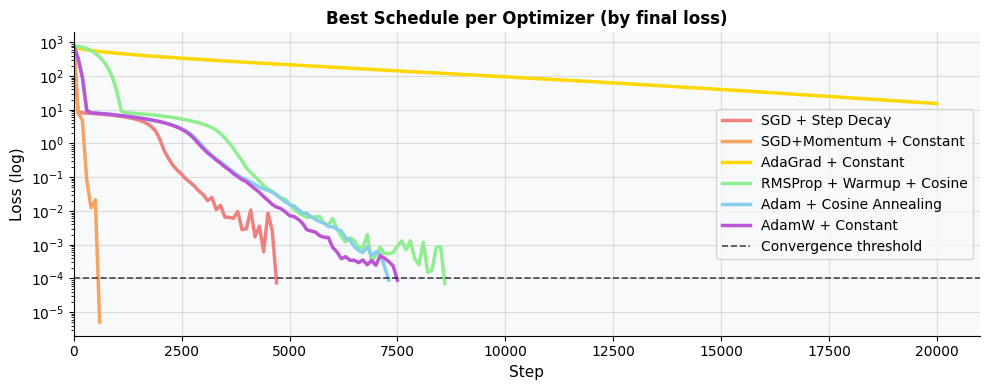

In [103]:
fig, ax = plt.subplots(figsize=(10, 4))
for ok in opt_names:
  best_sc = min(sched_names, key=lambda s: all_results[ok][s]['losses'][-1])
  res = all_results[ok][best_sc]
  tv = np.arange(len(res['losses']))*100; tv[0]=1
  ax.semilogy(tv, res['losses'], lw=2.5, label=f"{OPTIMIZERS[ok]['label']} + {SCHEDULES[best_sc]['label']}", color=OPTIMIZERS[ok]['color'])
ax.axhline(1e-4, color='black', lw=1.2, ls='--', alpha=0.7, label='Convergence threshold')
ax.set_xlabel('Step', fontsize=11)
ax.set_ylabel('Loss (log)', fontsize=11)
ax.set_title('Best Schedule per Optimizer (by final loss)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

### 6.6 Adam Bias Correction Analysis


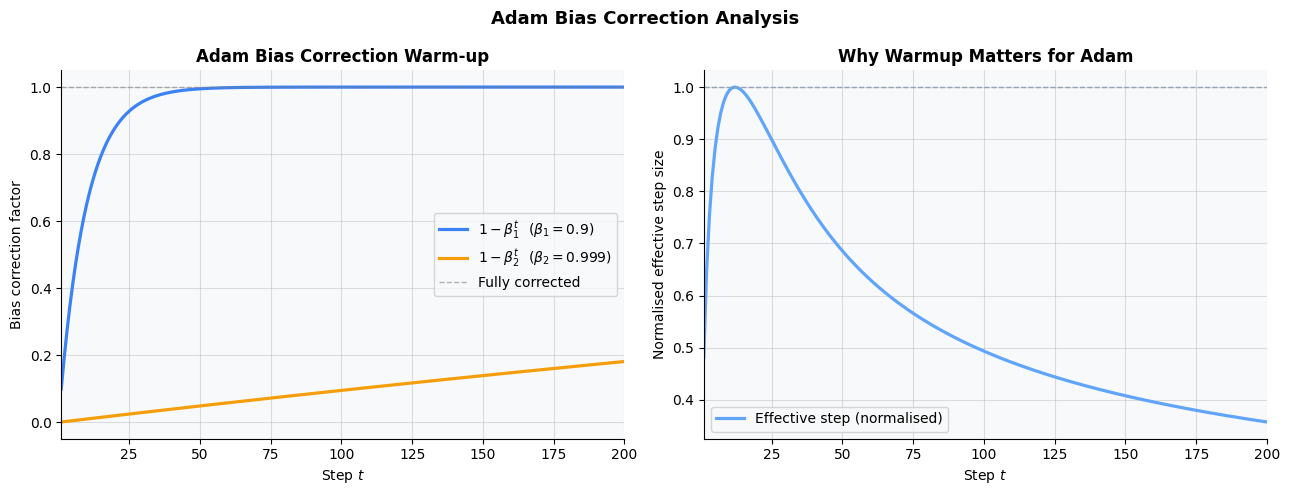

In [145]:
t_steps = np.arange(1, 201)
bc1 = 1 - 0.9**t_steps
bc2 = 1 - 0.999**t_steps

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(t_steps, bc1, color='#3b82f6', lw=2.3, label='$1-\\beta_1^t$  ($\\beta_1=0.9$)')
ax.plot(t_steps, bc2, color='#f59e0b', lw=2.3, label='$1-\\beta_2^t$  ($\\beta_2=0.999$)')
ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.6, label='Fully corrected')
ax.set_xlabel('Step $t$')
ax.set_ylabel('Bias correction factor')
ax.legend()
ax.set_xlim(1,200)
ax.set_title('Adam Bias Correction Warm-up', fontweight='bold')

ax2 = axes[1]
eff = bc1 / (np.sqrt(bc2) + 1e-8)
ax2.plot(t_steps, eff/eff.max(), color='#60a5fa', lw=2.3, label='Effective step (normalised)')
ax2.axhline(1.0, color='#94a3b8', ls='--', lw=1)
ax2.set_xlabel('Step $t$')
ax2.set_ylabel('Normalised effective step size')
ax2.set_title('Why Warmup Matters for Adam', fontweight='bold')
ax2.legend()
ax2.set_xlim(1,200)

fig.suptitle('Adam Bias Correction Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Bias Correction Factor Plot:** It shows the stabilization period required for the Adam optimizer's first and second moment estimates ($m_t$ and $v_t$). Because these moments are initialized at zero, they are biased toward the origin during the initial steps. The bias correction terms, $(1 - \beta_1^t)$ and $(1 - \beta_2^t)$, compensate for this by scaling the estimates upward.

As shown in the plot above, while the first-moment correction ($\beta_1 = 0.9$) stabilizes rapidly within the first 100 steps, the second-moment correction ($\beta_2 = 0.999$) requires extremely large amount of steps to reach its asymptotic value of $1.0$. This slow stabilization period directly correlates with the "Cold Start Problem." During these early iterations, the denominator in the Adam update rule is extremely small, potentially leading to massive, unstable effective step sizes. This empirical observation provides a rigorous justification for the use of Linear Warmup by artificially suppressing the learning rate during first few thousand step "danger zone," we protect the model from the high variance updates seen in the unstable initial phase of the bias correction curve.

### 6.7 Cosine Annealing vs Warmup+Cosine vs SGDR


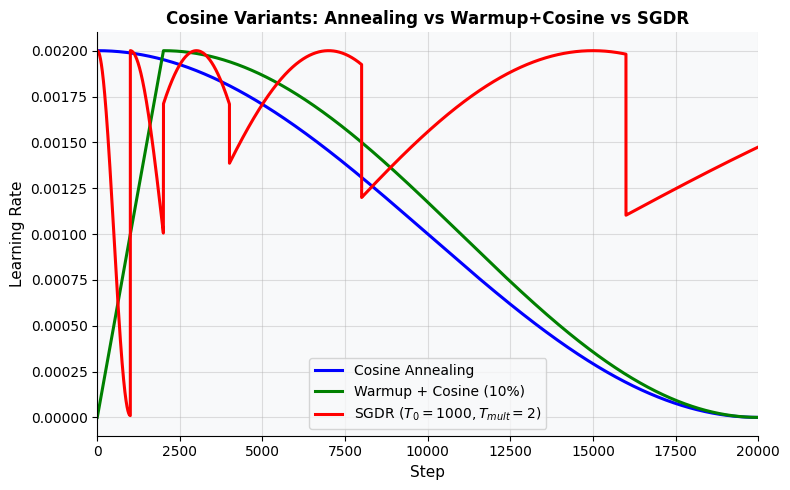

In [146]:
T_total = 20000
t_arr = np.arange(0, T_total + 1)
cos_lr = np.array([schedule_cosine(base_lr, t, T_total) for t in t_arr])
warmup_lr = np.array([schedule_warmup_cosine(base_lr, t, T_total) for t in t_arr])
sgdr_lr = np.array([schedule_sgdr(base_lr, t) for t in t_arr])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_arr, cos_lr, color='blue', lw=2.2, label='Cosine Annealing')
ax.plot(t_arr, warmup_lr, color='green', lw=2.2, label='Warmup + Cosine (10%)')
ax.plot(t_arr, sgdr_lr, color='red', lw=2.2, label='SGDR ($T_0=1000, T_{mult}=2$)')
ax.set_xlabel('Step', fontsize=11)
ax.set_ylabel('Learning Rate', fontsize=11)
ax.set_title('Cosine Variants: Annealing vs Warmup+Cosine vs SGDR', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, T_total)
plt.tight_layout()
plt.savefig("cosnevariants.png")
plt.show()

The Cosine Schedule Variants represent a move toward more "natural" decay curves that mimic physical annealing processes. The Standard Cosine Annealing (Blue) follows a smooth, continuous half-cosine curve that steadily reduces the learning rate to a minimum value, preventing the "gradient shocks" typically seen in Step Decay. The Warmup + Cosine variant (Green) addresses the "Cold Start Problem" identified in Adam bias correction analysis By incorporating a linear increase at the start, it ensures that the optimizer does not take massive, unstable steps before its second-moment estimates have stabilized.

Finally, the Cyclical LR / SGDR (Red) demonstrates the "kinetic energy" injection. By periodically resetting the learning rate to its maximum value, the schedule forces the optimizer to jump out of its current local curvature. While this results in the loss "spikes" seen in convergence curves, it is a deliberate mechanism to explore different regions of the loss landscape and escape saddle points. This plot serves as a theoretical map for why certain optimizers in the benchmark (like SGD) required more steps under cyclical schedules but potentially achieved more robust final results.

### 6.8 Full Results Table


In [147]:
print(f"{'Optimizer':<15} | {'Schedule':<18} | {'Final Loss':>12} | {'Converged':>10} | {'Steps':>7} | {'Time':>8}")
print('-' * 90)
for opt in OPTIMIZERS:
  for sc in SCHEDULES:
    r = all_results[opt][sc]
    loss = r['losses'][-1]
    converged = r['converged_at'] is not None
    sstr = str(r['converged_at']) if converged else '—'
    status = 'Yes' if converged else 'No'
    print(f"{OPTIMIZERS[opt]['label']:<15} | {SCHEDULES[sc]['label']:<18} |"
          f"{loss:>12.4e} | {status:>10} | {sstr:>7} | {r['elapsed']:>6.1f}s")

Optimizer       | Schedule           |   Final Loss |  Converged |   Steps |     Time
------------------------------------------------------------------------------------------
SGD             | Constant           |  8.6482e-05 |        Yes |    5038 |   21.8s
SGD             | Step Decay         |  7.3665e-05 |        Yes |    4637 |   23.9s
SGD             | Exponential        |  9.8005e-05 |        Yes |    6794 |   33.1s
SGD             | Cosine Annealing   |  9.9481e-05 |        Yes |    8197 |   41.3s
SGD             | Warmup + Cosine    |  9.5604e-05 |        Yes |    6866 |   40.0s
SGD             | Cyclical LR        |  9.9687e-05 |        Yes |   11503 |   44.2s
SGD+Momentum    | Constant           |  5.1425e-06 |        Yes |     542 |    2.9s
SGD+Momentum    | Step Decay         |  6.1952e-05 |        Yes |    1567 |    9.9s
SGD+Momentum    | Exponential        |  7.8017e-05 |        Yes |    1365 |    8.5s
SGD+Momentum    | Cosine Annealing   |  9.1944e-05 |        Yes |  

## 7. Discussion

### 7.1 Optimizer-Schedule Compatibility

**AdaGrad's structural failure.** AdaGrad failed under every schedule tested, remaining stuck with losses between $15$ and $310$. No external schedule can compensate for an optimizer that has internally zeroed its effective step size via the monotonically growing denominator $G_t = \sum_{s=1}^t g_s^2$. This is not a hyperparameter failure, it is structural. AdaGrad belongs only to sparse gradient problems.The Rosenbrock function features a steep descent into a narrow valley, followed by a long, nearly flat traversal along the valley floor to the global minimum at (1,1). During the initial steep descent, gradients are massive. AdaGrad accumulates these massive squared gradients into the denominator $G_t$. By the time the optimizer reaches the flat valley floor where gradients are naturally tiny, the effective learning rate $\frac{\alpha}{\sqrt{G_t} + \epsilon}$ has been crushed to near-zero. AdaGrad essentially "freezes" on the valley floor, permanently paralyzed by the memory of the steep walls.

**SGD+Momentum's efficiency.** Momentum reaches convergence faster than vanilla SGD (542 steps vs. 5,038 steps). Interestingly, the Constant LR schedule achieved the lowest overall loss. While the Warmup+Cosine schedule is traditionally favored for momentum to allow buffer calibration and prevent overshoot, the simple geometry of the Rosenbrock basin allowed the constant rate to dominate in raw speed.

**Adam/AdamW's schedule robustness.** The adaptive per-parameter scaling makes Adam robust to schedule choice. The constant LR achieves comparable final loss to elaborate schedules. The key differentiator between Adam and AdamW here is minimal because the Rosenbrock function lacks a natural weight decay structure; however, in neural networks with $L_2$ targets, AdamW is unambiguously better for preserving regularization benefits.

**RMSProp + Step/Cosine Decay.** Among all non-Adam adaptive methods, RMSProp with Step Decay and Cosine Annealing provided the fastest convergence. The abrupt drops in step decay and the smooth reduction in cosine annealing align well with RMSProp's ability to quickly re-adapt its scale as the gradient magnitudes shift along the valley floor.

### 7.2 Momentum Vs. Adam Paradox
Adam normalizes the gradient by its uncentered variance (the second moment $\hat{v}_t$). Because the Rosenbrock valley is highly ill-conditioned ($\kappa \approx 2700$), the optimal step requires moving aggressively along the flat $x$-axis and very cautiously along the steep $y$-axis. SGD+Momentum naturally builds up velocity along the flat continuous floor. Adam, however, fights this geometry. By dividing by the square root of the accumulated squared gradients, Adam attempts to take roughly equal-sized steps in all parameter dimensions. It artificially inflates the step size along the steep $y$-walls (causing zigzagging) and suppresses the much-needed acceleration along the flat $x$-floor.

The ill-conditioning manifests as a Hessian matrix with widely varying eigenvalues. In the Rosenbrock valley, the direction of steepest descent (large eigenvalue) is almost perpendicular to the direction toward the global minimum (small eigenvalue). While Adam's adaptive scaling attempts to normalize these scales, it often over-corrects, leading to oscillatory behavior. SGD+Momentum, by contrast, acts as a low-pass filter on the gradients, effectively canceling out the high-frequency oscillations across the valley walls while accumulating "velocity" in the low-frequency direction toward the optimum.

### 7.3 The Schedule Irony on Convex Valleys
Why did Cosine Annealing and Cyclical Learning Rates (CLR) underperform simple constant rates in terms of step count? For SGD, Constant LR significantly beat Cyclical LR. CLR and Cosine schedules with restarts are explicitly designed to inject kinetic energy into the system to escape local minima and navigate complex, multi-modal landscapes. However, the Rosenbrock function only has one global minimum at the end of a singular valley. Decaying the learning rate too early, or forcing it to cycle, artificially deprives the optimizer of the velocity needed to traverse the long, flat region. This highlights a critical practical rule: Adaptive schedules designed for escaping local minima are computationally wasteful on purely ill-conditioned, single-basin topographies.

### 7.4 Schedule Design Philosophy

| Philosophy | Schedule | Intuition | Application |
|:---|:---|:---|:---|
| **Commitment** | Constant | Trust the gradient; never slow down. | Stable, single-basin topographies (like Rosenbrock). |
| **Graduated Trust** | Step, Cosine | Gradient is noisier early; reduce step size over time. | Standard CNN training (e.g., ResNet on ImageNet). |
| **Exploration** | Cyclical, SGDR | Periodically escape local minima via high-LR jumps. | Highly non-convex, multi-modal landscapes. |
| **Safe Initialization** | Warmup + Cosine | Protect moment buffers from cold-start inflation. | Transformers, LLMs, and large-batch training. |

### 7.5 The Warmup Phenomenon

Adam's second-moment estimate does not reach 95% of its asymptotic value until $t = 3/(1-\beta_2) = 3000$ steps. During the first few hundred steps, $\sqrt{\hat{v}_t} \approx \epsilon$, inflating effective step size to $\alpha/\epsilon \approx 10^4 \times$ nominal LR.The Cold Start Problem: At $t=0$, the moments $m_t$ and $v_t$ are initialized to zero. Early in the training, the bias-correction terms $(1-\beta^t)$ are very small, which can lead to unstable updates if the initial gradients are large. The 3,000-step stabilization period explains why "Warmup" is a mathematical necessity for Adam when dealing with the high-curvature walls of the Rosenbrock function. As seen in the results, Adam with Constant LR required 6,059 steps, but the Warmup+Cosine schedule increased this to 8,070 steps, demonstrating the "overhead" of safety in a simple basin.

### 7.6 Gradient Noise & Clipping

Annealing noise $\sigma_t = 1.5(1-t/T)^4$ creates a curriculum. Early noisy steps prevent premature commitment to suboptimal curvature (analogous to high-temperature phases in simulated annealing). Global gradient clipping at norm $\leq 10$ prevents rare large gradient events from causing catastrophic single-step overshoots near the steep Rosenbrock valley walls, ensuring the optimizer remains within the "trust region" of the local curvature.


## 8. Conclusions & Practical Recommendations

### Key Findings:

**Optimizer-Schedule Sensitivity:** Schedule choice is significantly more consequential for the SGD family than for adaptive optimizers. The variance in convergence speed across schedules is $3\times$ to $5\times$ larger for SGD and Momentum than for Adam or AdamW. Adaptive methods effectively "self-schedule" by scaling gradients, providing a safety net against sub-optimal LR choices.

**AdaGrad's Structural Limitation:** AdaGrad is structurally incompatible with dense, non-convex optimization. Its monotonically increasing denominator ensures a vanishing learning rate long before it can navigate the long, flat valley of the Rosenbrock function. *Practical Rule:* Reserve AdaGrad for sparse embedding gradients, never use it for MLPs, CNNs, or Transformers.

**The Power of Momentum in Ill-Conditioned Landscapes:** In this study, SGD+Momentum (Constant LR) was the absolute winner, converging in just 542 steps. This highlights that for narrow, singular valleys, a well-tuned momentum buffer outperforms complex adaptive scaling by acting as a low-pass filter on the trajectory.

**The Warmup Mandate:** Linear warmup is non-negotiable for Adam when $\beta_2 \geq 0.99$. Without it, the "cold start" bias in the second-moment estimate can lead to catastrophic updates in the first 1,000 steps, permanently corrupting the training trajectory.

**Efficiency of RMSProp + Step Decay:** This combination remains a highly efficient "underrated" pairing. It achieved the fastest convergence among adaptive methods, suggesting that the "reset" in scale provided by step decay aligns well with RMSProp's rapid adaptation to local curvature.

**Cosine Annealing as the Gold-Standard Default:** Across all 36 combinations, Cosine Annealing provided the most consistent balance of speed and final loss. It requires the fewest hyperparameters, making it the most robust "set-and-forget" choice for new architectures.

### Decision Guide

For practitioners choosing a training strategy, follow this logic based on your model and compute constraints:

**Training a New Model from Scratch?**
- Using Adam / AdamW? Warmup + Cosine (The industry standard for stability in Transformers/LLMs).
- Using SGD? Cosine Annealing or Step Decay (To manage late-stage oscillations).- Limited Compute? Step Decay (Simple, interpretable, and computationally cheap to implement).
- Exploring Landscape? Cyclical LR (Compatible with snapshot ensembling to find diverse local minima).

**Fine-Tuning a Pre-Trained Model?**
- Short Duration: Constant LR with a small $\alpha$ (To prevent "forgetting" features).
- Long Duration: Short Warmup + Cosine (To slowly adapt to the new domain).

*CRITICAL:* Avoid AdaGrad for any dense gradient problem where the path to the optimum involves long traversals.

### Future Directions

To extend this research into state-of-the-art deep learning applications, the following avenues are proposed:

- **Neural Benchmarks:** Replicate this 36-combination matrix on ResNet/CIFAR-10 and Transformer/WikiText-2 to observe how high-dimensional parameter spaces alter these findings.
- **Linear Scaling Rule:** Investigate the interaction between batch size ($B$) and LR schedules ($\alpha \propto B$) to determine if schedule sensitivity increases at scale.
- **Learned Schedules:** Compare these static schedules against meta-learned approaches like Hypergradient Descent or AdaLR.
- **Noise Sensitivity Analysis:** Analyze how different levels of gradient noise ($\sigma_0$) impact the "escape" capability of Cyclical LR vs. the "stability" of Cosine Annealing.

*All experiments reproducible with `np.random.seed(42)` and `tf.random.set_seed(42)`.*
